In [1]:
import pandas as pd, networkx as nx
from networkx.drawing.nx_agraph import graphviz_layout

from helpers.load_payload import load_payload
from helpers.aggregated_qv import plot_aggregated_qv_grid
from helpers.success_fraction import plot_qv_success_fraction_grid
from helpers.different_modes import plot_mode_comparison_grid
from helpers.best_and_worst import plot_best_worst_grid

In [2]:
def coupling_to_graph(coupling_map):
    G = nx.Graph()
    G.add_edges_from((int(a), int(b)) for a, b in coupling_map)
    return G

In [3]:
def summarize_qv_results(q_values, results_dir="results"):
    rows = []

    for q in q_values:
        df = pd.read_csv(f"{results_dir}/ibm_marrakesh_qv_{q}_tuples_optimised.csv")

        mean_hop = df["mean_HOP"].mean()
        mean_error = df["hop_error"].mean()

        rows.append({
            "n": q,
            "count": len(df),
            "mean_HOP": mean_hop,
            "std_HOP": df["mean_HOP"].std(ddof=1),
            "median_HOP": df["mean_HOP"].median(),
            "min_HOP": df["mean_HOP"].min(),
            "max_HOP": df["mean_HOP"].max(),
            "mean_error": mean_error,
            "lower_bound": mean_hop - 1.96 * mean_error,
        })

    out = pd.DataFrame(rows)
    return out

In [4]:
summary_df = summarize_qv_results([3, 4, 5, 6])

summary_df_rounded = summary_df.copy()
for col in summary_df_rounded.columns:
    if col != "n" and col != "count":
        summary_df_rounded[col] = summary_df_rounded[col].map(lambda x: f"{x:.3f}")

summary_df_rounded = summary_df_rounded.rename(columns={
    "n": "$n$",
    "count": "Count",
    "mean_HOP": r"$\langle HOP \rangle$",
    "std_HOP": r"$\sigma(HOP)$",
    "median_HOP": "Median",
    "min_HOP": "Min",
    "max_HOP": "Max",
    "mean_error": r"$\langle SE \rangle$",
    "lower_bound": "Lower",
})

summary_df_rounded.to_latex(
    "results/qv_summary_stats_optimised.tex",
    index=False,
    escape=False
)

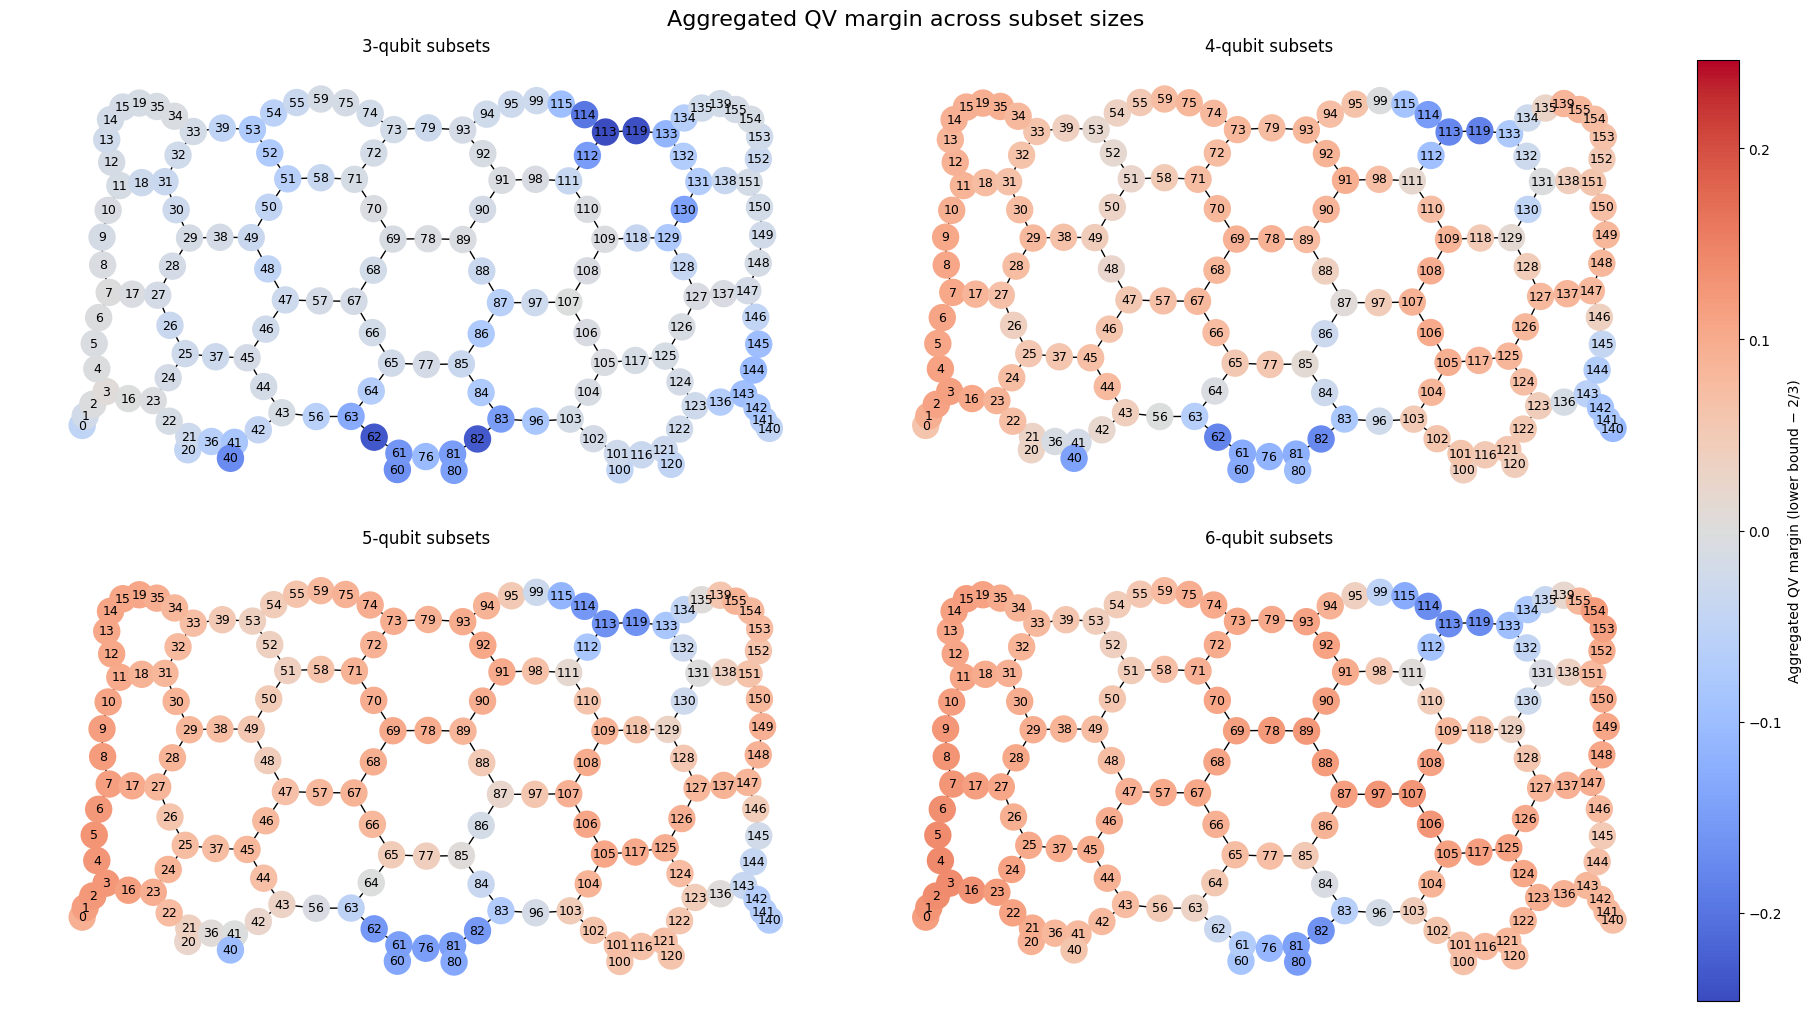

In [5]:
calibration = "calibrations/ibm_marrakesh/20260129_101824.json"
coupling_map = load_payload(calibration)["coupling_map"]

G = coupling_to_graph(coupling_map)
pos = graphviz_layout(G, prog="sfdp")

dfs_by_q = {}
for q in [3, 4, 5, 6]:
    dfs_by_q[q] = pd.read_csv(f"results/ibm_marrakesh_qv_{q}_tuples.csv")

plot_aggregated_qv_grid(G, pos, dfs_by_q)

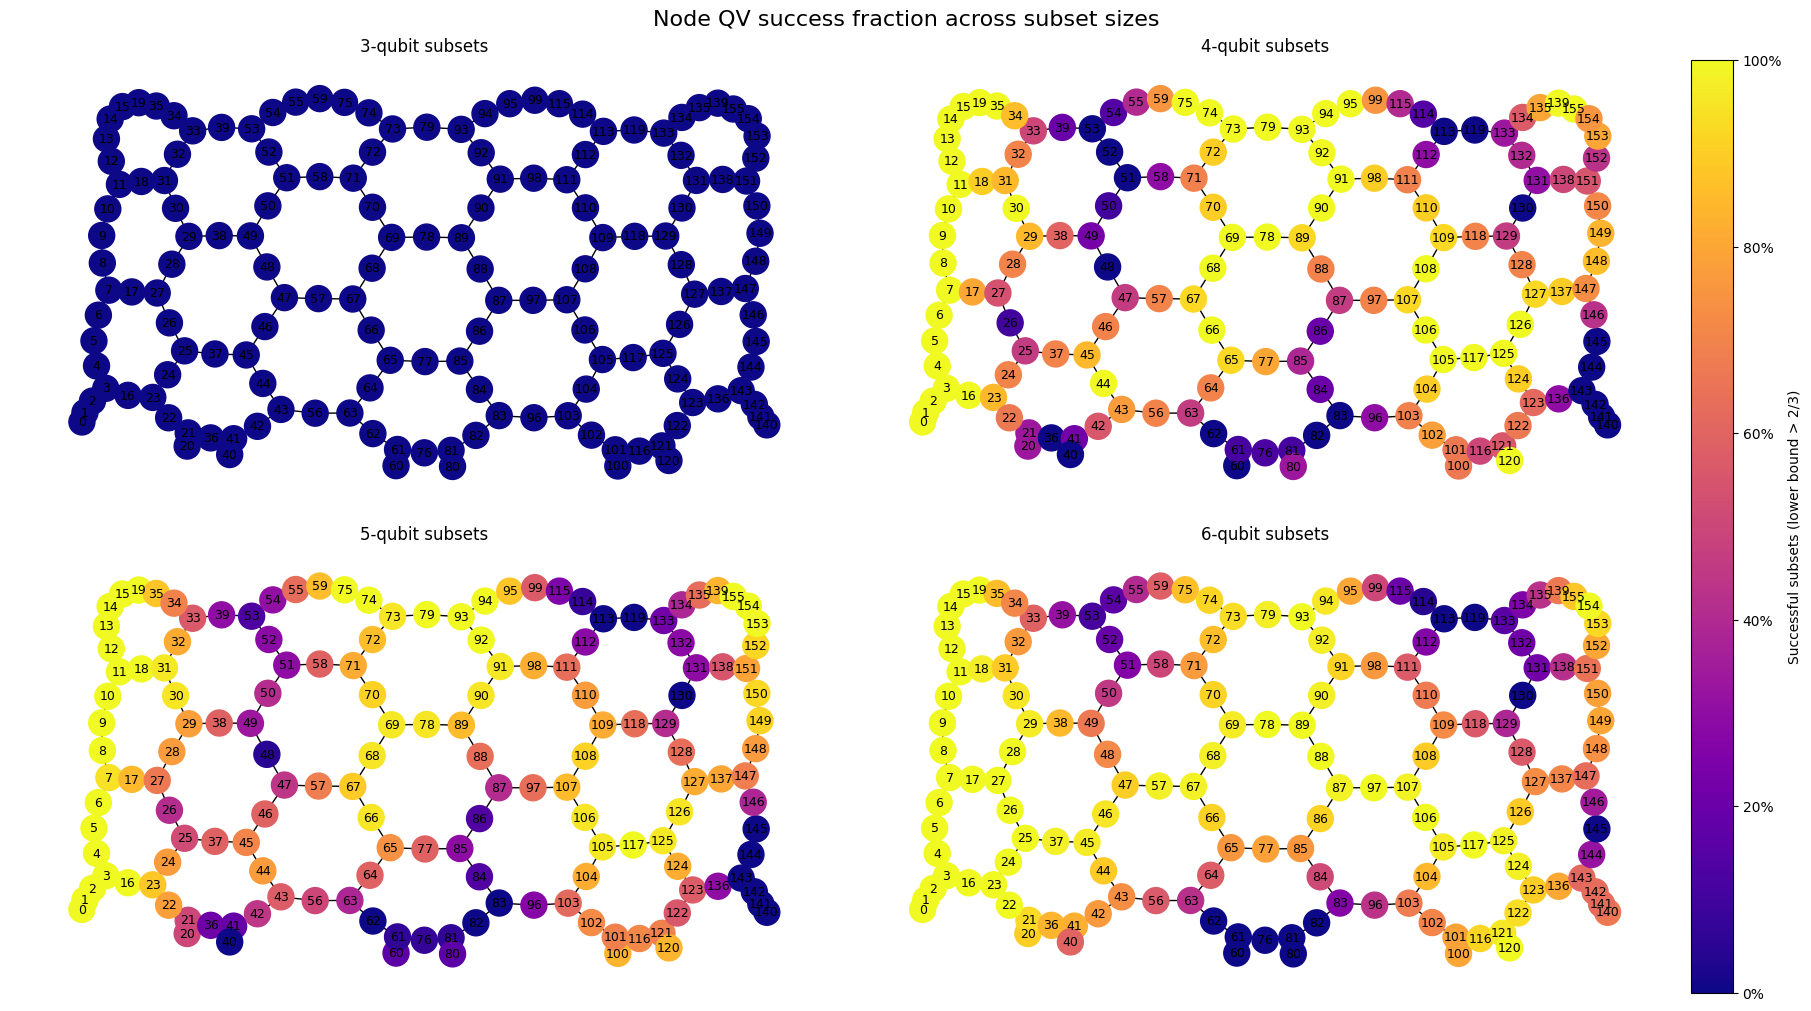

In [6]:
dfs_by_q = {}
for q in [3, 4, 5, 6]:
    dfs_by_q[q] = pd.read_csv(f"results/ibm_marrakesh_qv_{q}_tuples.csv")

plot_qv_success_fraction_grid(G, pos, dfs_by_q)

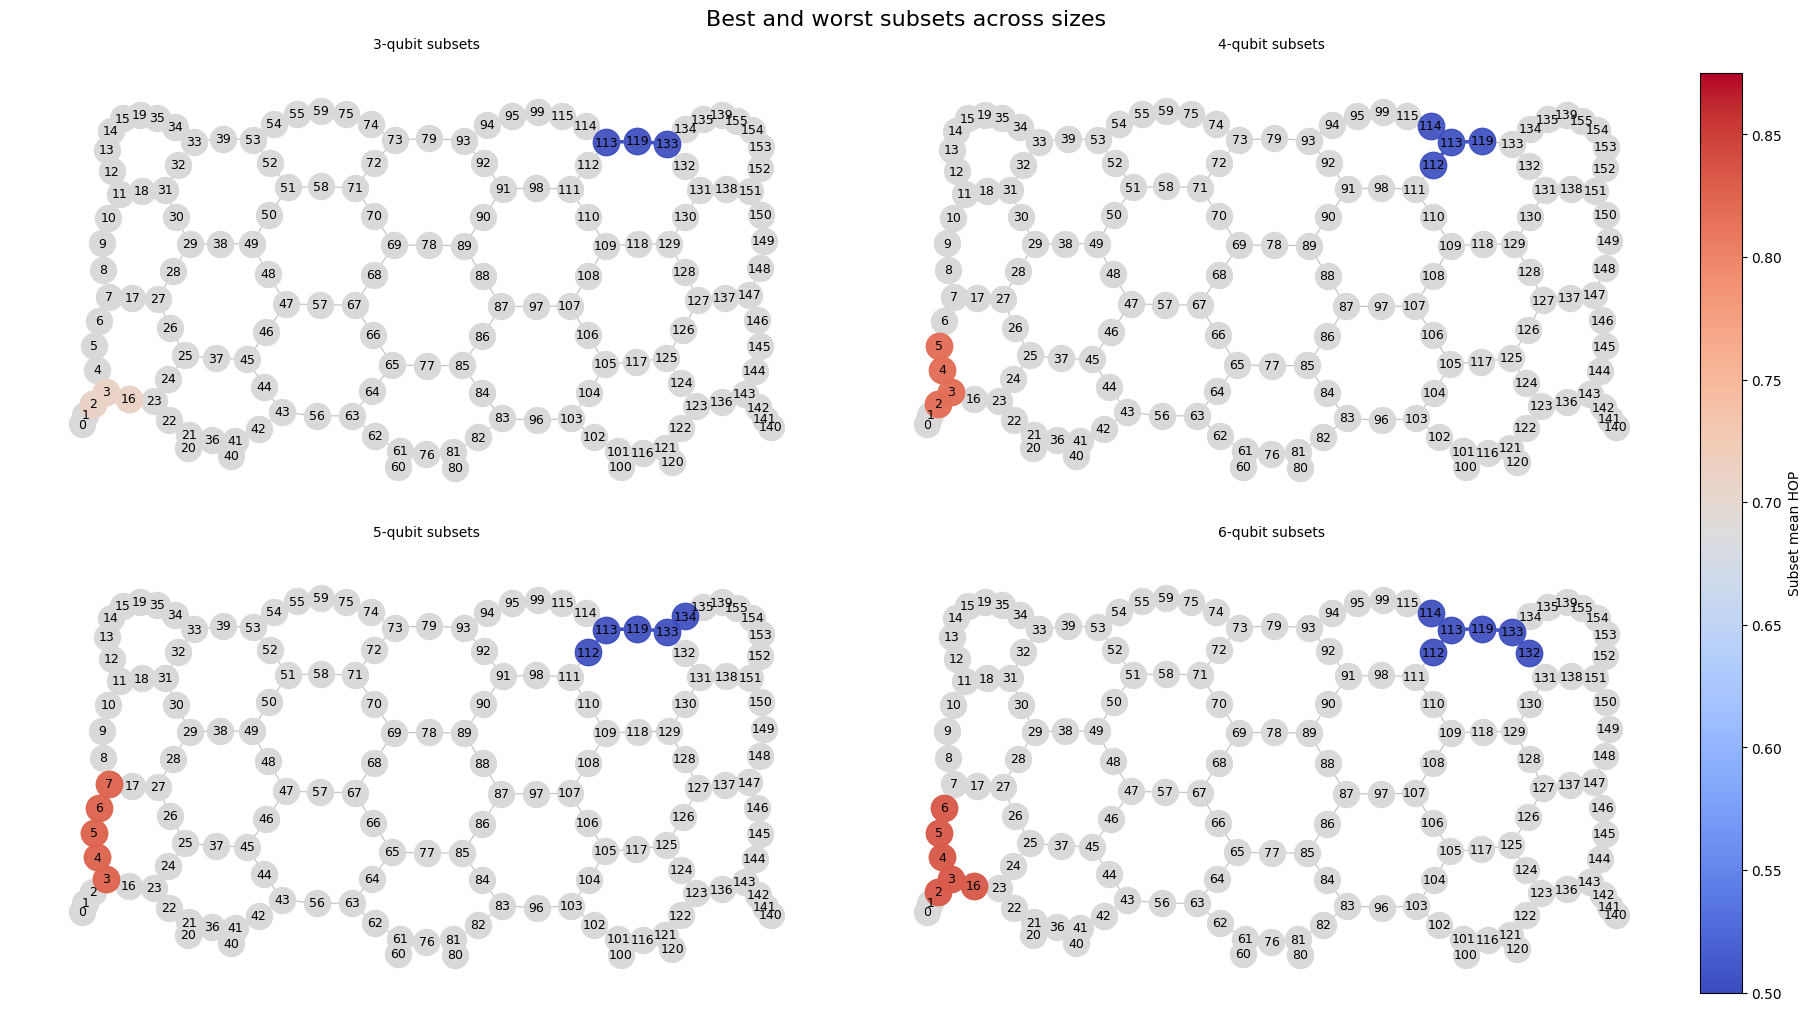

In [7]:
dfs_by_q = {}
for q in [3, 4, 5, 6]:
    dfs_by_q[q] = pd.read_csv(f"results/ibm_marrakesh_qv_{q}_tuples.csv")

plot_best_worst_grid(G, pos, dfs_by_q)

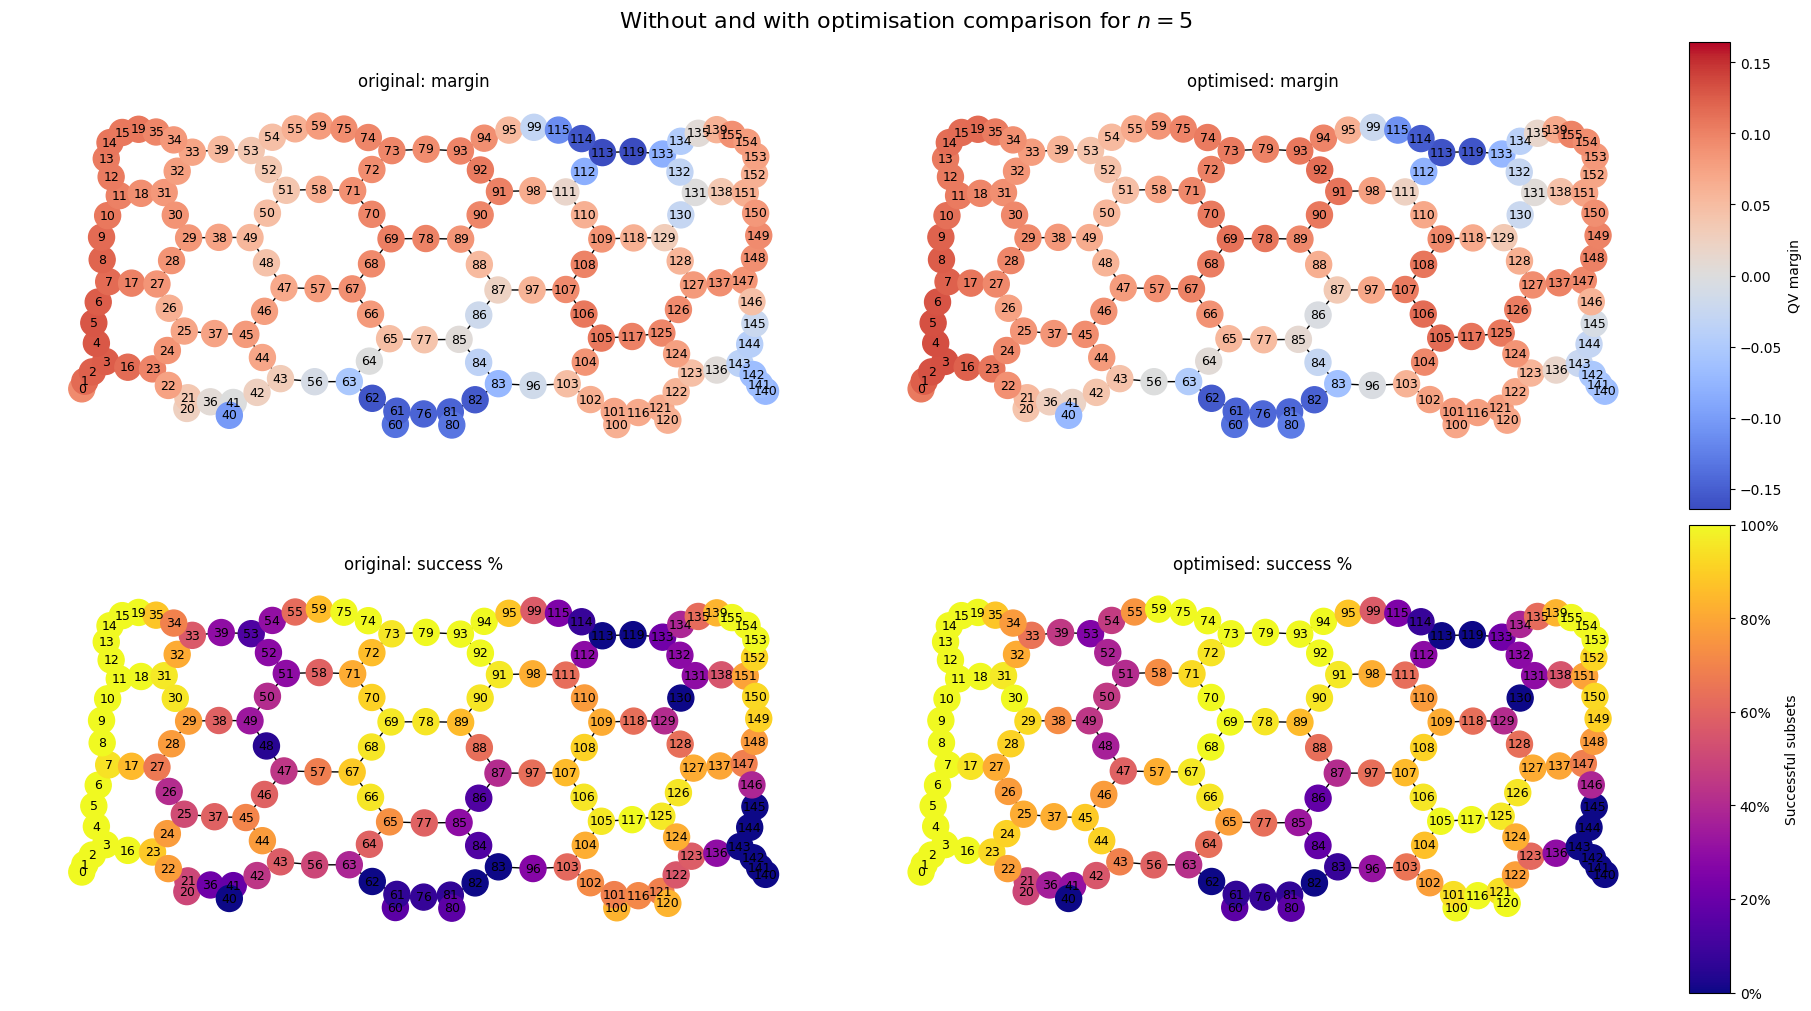

In [9]:
dfs_by_mode = {
    "original": pd.read_csv(f"results/ibm_marrakesh_qv_5_tuples.csv"),
    "optimised": pd.read_csv(f"results/ibm_marrakesh_qv_5_tuples_optimised.csv")
}

plot_mode_comparison_grid(G, pos, dfs_by_mode, q=5)